In [ ]:
pwd()

'/teamspace/studios/this_studio'

In [1]:
!pip install split-folders
!pip install tqdm
!pip install nibabel
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install torch torchvision
!pip install torchmetrics
!pip install torchinfo
!pip install segmentation-models-pytorch-3d
!pip install livelossplot
!pip install dataclasses
!pip install gc
!pip install segmentation-models-pytorch

ERROR: Could not find a version that satisfies the requirement gc (from versions: none)
ERROR: No matching distribution found for gc


In [7]:
import random
import splitfolders
from tqdm import tqdm
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import shutil
import time
import os
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from torch.cuda import amp

from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
import gc

import segmentation_models_pytorch_3d as smp

from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot, ExtremaPrinter
from torch.optim import AdamW

In [2]:
import os
print(os.cpu_count())

30


In [3]:
mpress-program="pigz -p 30" -xf /teamspace/studios/this_studio/input_data_3channels_combined.tar.gz -C /teamspace/studios/this_studio/!tar --use-co

In [12]:
# Path to combined data
data_dir = '/teamspace/studios/this_studio/input_data_3channels_combined/'

# Output directories
output_dirs = [
    '/teamspace/studios/this_studio/data_train/',
    '/teamspace/studios/this_studio/data_test/'
]

# Create output directories
for d in output_dirs:
    os.makedirs(d, exist_ok=True)

# Get all .npz files
data_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npz')])
n_files = len(data_files)
n_train = int(0.85 * n_files)

# Shuffle with fixed seed
np.random.seed(42)
indices = np.random.permutation(n_files)

train_indices = indices[:n_train]
test_indices = indices[n_train:]

print(f"Total files: {n_files}")
print(f"Train: {len(train_indices)}, Test: {len(test_indices)}")

# Copy train files
for idx in train_indices:
    data_file = data_files[idx]
    shutil.copy2(os.path.join(data_dir, data_file),
                 os.path.join('/teamspace/studios/this_studio/data_train/', data_file))

# Copy test files
for idx in test_indices:
    data_file = data_files[idx]
    shutil.copy2(os.path.join(data_dir, data_file),
                 os.path.join('/teamspace/studios/this_studio/data_test/', data_file))

print("Split complete!")
print(f"Train files: {len(os.listdir('/teamspace/studios/this_studio/data_train/'))}")
print(f"Test files: {len(os.listdir('/teamspace/studios/this_studio/data_test/'))}")

Total files: 935
Train: 794, Test: 141


Split complete!
Train files: 794
Test files: 141


In [13]:
class BraTSDataset(Dataset):
  def __init__(self, data_dir):
      super().__init__()
      self.data_dir = data_dir
      self.file_list = sorted([f for f in os.listdir(data_dir) if f.endswith('.npz')])


  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, index):
    file_path = os.path.join(self.data_dir, self.file_list[index])
    data = np.load(file_path)
    image = data['image']
    mask = data['mask']

    image = torch.from_numpy(image).permute(3, 0, 1, 2).float()
    mask = torch.from_numpy(mask).long()
    return image, mask

In [28]:
%%time
train_dataset = BraTSDataset(data_dir='/teamspace/studios/this_studio/data_train/')
val_dataset = BraTSDataset(data_dir='/teamspace/studios/this_studio/data_test/')
print("Total Training Samples: ", len(train_dataset))
print("Total Val Samples: ", len(val_dataset))


train_loader = DataLoader(train_dataset, batch_size = 8, shuffle = True, num_workers = 16, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle = False, num_workers = 16, pin_memory=True, persistent_workers=True,prefetch_factor=2)
#val_loader = DataLoader(val_dataset, batch_size = 1, shuffle = False, num_workers = 4)

# Sanity Check - Train
images, masks = next(iter(train_loader))
print(f"Train Image batch shape: {images.shape}")  # Expected: (batch_size, 3, 142, 178, 142)
print(f"Train Mask batch shape: {masks.shape}")    # Expected: (batch_size, 142, 178, 142)
print(f"Train Image range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Train Mask unique labels: {torch.unique(masks)}")

# Sanity Check - Val/Test
images, masks = next(iter(val_loader))
print(f"\nVal Image batch shape: {images.shape}")
print(f"Val Mask batch shape: {masks.shape}")
print(f"Val Image range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Val Mask unique labels: {torch.unique(masks)}")

Total Training Samples:  794
Total Val Samples:  141
Train Image batch shape: torch.Size([8, 3, 142, 178, 142])
Train Mask batch shape: torch.Size([8, 142, 178, 142])
Train Image range: [-0.938, 166.440]
Train Mask unique labels: tensor([0, 1, 2, 3, 4])

Val Image batch shape: torch.Size([8, 3, 142, 178, 142])
Val Mask batch shape: torch.Size([8, 142, 178, 142])
Val Image range: [-0.955, 191.602]
Val Mask unique labels: tensor([0, 1, 2, 3, 4])
CPU times: user 6.33 s, sys: 23.4 s, total: 29.7 s
Wall time: 24.7 s


In [18]:
#Define the double_conv function
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm3d(out_channels),  # Add BatchNorm3d after second convolution
        nn.ReLU(inplace=True),
        #the dropout was making it slow, removed for now...24_12_2025
        #nn.Dropout3d(0.1),
        nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm3d(out_channels),
        nn.ReLU(inplace=True)
    )


class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Contraction path
        self.conv1 = double_conv(in_channels=in_channels, out_channels=16)
        self.pool1 = nn.MaxPool3d(kernel_size=2)

        self.conv2 = double_conv(in_channels=16, out_channels=32)
        self.pool2 = nn.MaxPool3d(kernel_size=2)

        self.conv3 = double_conv(in_channels=32, out_channels=64)
        self.pool3 = nn.MaxPool3d(kernel_size=2)

        self.conv4 = double_conv(in_channels=64, out_channels=128)
        self.pool4 = nn.MaxPool3d(kernel_size=2)

        self.conv5 = double_conv(in_channels=128, out_channels=256)

        # Expansive path
        self.upconv6 = nn.ConvTranspose3d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.conv6 = double_conv(in_channels=256, out_channels=128)

        self.upconv7 = nn.ConvTranspose3d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.conv7 = double_conv(in_channels=128, out_channels=64)

        self.upconv8 = nn.ConvTranspose3d(in_channels=64, out_channels=32, kernel_size=2, stride=2)
        self.conv8 = double_conv(in_channels=64, out_channels=32)

        self.upconv9 = nn.ConvTranspose3d(in_channels=32, out_channels=16, kernel_size=2, stride=2)
        self.conv9 = double_conv(in_channels=32, out_channels=16)

        self.out_conv = nn.Conv3d(in_channels=16, out_channels=out_channels, kernel_size=1)

    def forward(self, x):
        # Contracting path
        c1 = self.conv1(x)
        p1 = self.pool1(c1)

        c2 = self.conv2(p1)
        p2 = self.pool2(c2)

        c3 = self.conv3(p2)
        p3 = self.pool3(c3)

        c4 = self.conv4(p3)
        p4 = self.pool4(c4)

        c5 = self.conv5(p4)

        # Expansive path with interpolation to match sizes
        u6 = self.upconv6(c5)
        u6 = F.interpolate(u6, size=c4.shape[2:], mode='trilinear', align_corners=False)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.conv6(u6)

        u7 = self.upconv7(c6)
        u7 = F.interpolate(u7, size=c3.shape[2:], mode='trilinear', align_corners=False)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.conv7(u7)

        u8 = self.upconv8(c7)
        u8 = F.interpolate(u8, size=c2.shape[2:], mode='trilinear', align_corners=False)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.conv8(u8)

        u9 = self.upconv9(c8)
        u9 = F.interpolate(u9, size=c1.shape[2:], mode='trilinear', align_corners=False)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.conv9(u9)

        outputs = self.out_conv(c9)

        return outputs
#ACTUALLY DEFINING THE MODEL U DUMBFUCK
model = UNet3D(in_channels=3, out_channels=5)
print(model)

#Create a random input tensor
ip_tensor = torch.randn(1, 3, 142, 178, 142)

#Forward pass through the model
output = model(ip_tensor)

# Print input and output shapes
print("-" * 260)
print(f"Input shape: {ip_tensor.shape}")
print(f"Output shape: {output.shape}")

UNet3D(
  (conv1): Sequential(
    (0): Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool3d(kernel_size=2, stride=2, pad

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Input shape: torch.Size([1, 3, 142, 178, 142])
Output shape: torch.Size([1, 5, 142, 178, 142])


In [19]:
# Define Dice and Focal loss functions
dice_loss = smp.losses.DiceLoss(
    mode="multiclass",          # For multi-class segmentation
    classes=None,               # Compute the loss for all classes
    log_loss=False,             # Do not use log version of Dice loss
    from_logits=True,           # Model outputs are raw logits
    smooth=1e-5,                # A small smoothing factor for stability
    ignore_index=None,          # Don't ignore any classes
    eps=1e-7                    # Epsilon for numerical stability
)

# Focal Loss with optional class balancing via alpha
focal_loss = smp.losses.FocalLoss(
    mode="multiclass",          # Multi-class segmentation
    alpha=None,                 # class weighting to deal with class imbalance -> CLAUDE SUGGESTED TO TRY AN NOT BALANCE DATA
    gamma=2.0                   # Focusing parameter for hard-to-classify examples
)


def combined_loss(output, target):
  loss1 = dice_loss(output, target)
  loss2 = focal_loss(output, target)
  return 0.5*loss1 + 0.5*loss2

In [29]:
def train_one_epoch(
      model,
      loader,
      optimizer,
      num_classes,
      device="cuda",
      epoch_idx=800,
      total_epochs=10):

      model.train()
      scaler = torch.amp.GradScaler('cuda')
      loss_record = MeanMetric().to(device)
      metric_record = MeanMetric().to(device)
      acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro').to(device)
      loader_len = len(loader)

      # ADD GRADIENT ACCUMULATION
      accumulation_steps = 2

      with tqdm(total=loader_len, ncols=122) as tq:
          tq.set_description(f"Train ::  Epoch: {epoch_idx}/{total_epochs}")

          for batch_idx, (data, target) in enumerate(loader):
              tq.update(1)
              data, target = data.to(device, non_blocking=True).float(), target.to(device, non_blocking=True).long()

              with torch.amp.autocast('cuda'):
                  output_dict = model(data)
                  loss = combined_loss(output_dict, target) / accumulation_steps  # DIVIDE BY ACCUMULATION

              scaler.scale(loss).backward()

              # ONLY STEP EVERY ACCUMULATION_STEPS
              if (batch_idx + 1) % accumulation_steps == 0:
                  scaler.unscale_(optimizer)
                  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                  scaler.step(optimizer)
                  scaler.update()
                  optimizer.zero_grad()

              # COMPUTE METRICS ONLY EVERY 10 BATCHES
              if batch_idx % 10 == 0:
                  with torch.no_grad():
                      pred_idx = output_dict.argmax(dim=1)
                      tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
                      metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')

                      acc_record.update(pred_idx, target)  # REMOVE .cpu()
                      metric_record.update(metric_macro, weight=data.shape[0])  # REMOVE .cpu()

              loss_record.update(loss.detach() * accumulation_steps, weight=data.shape[0])  # MULTIPLY BACK

              # UPDATE PROGRESS BAR EVERY 10 BATCHES
              if batch_idx % 10 == 0:
                  tq.set_postfix_str(s=f"Loss: {loss_record.compute():.4f}, IOU: {metric_record.compute():.4f}, Acc: {acc_record.compute():.4f}")

      return loss_record.compute().cpu(), metric_record.compute().cpu(), acc_record.compute().cpu()

def validate(
      model,
      loader,
      num_classes,
      device="cuda",
      epoch_idx=800,
      total_epochs=10):

      model.eval()
      loss_record = MeanMetric().to(device)  # ADD .to(device)
      metric_record = MeanMetric().to(device)  # ADD .to(device)
      acc_record = MulticlassAccuracy(num_classes=num_classes, average='macro').to(device)  # ADD .to(device)
      loader_len = len(loader)

      with tqdm(total=loader_len, ncols=122) as tq:
          tq.set_description(f"Valid ::  Epoch: {epoch_idx}/{total_epochs}")

          for batch_idx, (data, target) in enumerate(loader):
              tq.update(1)
              data, target = data.to(device, non_blocking=True).float(), target.to(device, non_blocking=True).long()

              with torch.no_grad():
                  output_dict = model(data)
                  loss = combined_loss(output_dict, target)

                  # COMPUTE METRICS ONLY EVERY 10 BATCHES
                  if batch_idx % 10 == 0:
                      pred_idx = output_dict.argmax(dim=1)
                      tp, fp, fn, tn = smp.metrics.get_stats(pred_idx, target, mode='multiclass', num_classes=num_classes)
                      metric_macro = smp.metrics.iou_score(tp, fp, fn, tn, reduction='macro')

                      acc_record.update(pred_idx, target)  # REMOVED .cpu()
                      metric_record.update(metric_macro, weight=data.shape[0])  # REMOVED .cpu()

                  loss_record.update(loss, weight=data.shape[0])  # REMOVED .cpu()

              # UPDATE PROGRESS BAR EVERY 10 BATCHES
              if batch_idx % 10 == 0:
                  tq.set_postfix_str(s=f"Loss: {loss_record.compute():.4f}, IOU: {metric_record.compute():.4f}, Acc: {acc_record.compute():.4f}")

          valid_epoch_loss = loss_record.compute().cpu()
          valid_epoch_metric = metric_record.compute().cpu()
          valid_epoch_acc = acc_record.compute().cpu()

      return valid_epoch_loss, valid_epoch_metric, valid_epoch_acc

In [21]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=0.005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

In [22]:
def create_checkpoint_dir(checkpoint_dir):
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    try:
        num_versions = [int(i.split("_")[-1]) for i in os.listdir(checkpoint_dir) if "version" in i]
        version_num = max(num_versions) + 1

    except:
        version_num = 0

    version_dir = os.path.join(checkpoint_dir, "version_" + str(version_num))
    os.makedirs(version_dir)

    print(f"Checkpoint directory: {version_dir}")
    return version_dir

In [23]:
def seed_everything(SEED):
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def get_default_device():
    gpu_available = torch.cuda.is_available()
    return torch.device('cuda' if gpu_available else 'cpu'), gpu_available

In [43]:
@dataclass(frozen=True)
class TrainingConfig:
    # Training
    EPOCHS:          int = 100      
    LEARNING_RATE: float = 1e-3     # Lower for full dataset (794 samples)
    WEIGHT_DECAY:  float = 1e-4     # Add light regularization
    
    # Paths
    CHECKPOINT_DIR:  str = os.path.join('model_checkpoint', '3D_UNet_Brats2024')
    
    # Early stopping
    PATIENCE:        int = 10       # Increased for full dataset
    MIN_DELTA:     float = 0.001    # Minimum improvement threshold

In [25]:
DEVICE, GPU_AVAILABLE = get_default_device()
print(f"Using device: {DEVICE}")
CKPT_DIR = create_checkpoint_dir(TrainingConfig.CHECKPOINT_DIR)
seed_everything(SEED = 42)

Using device: cuda
Checkpoint directory: model_checkpoint/3D_UNet_Brats2024/version_0


In [44]:
model = UNet3D(in_channels=3, out_channels=5).to(DEVICE) 

In [33]:
print("\nModel initialization check...")
with torch.no_grad():
    test_batch = next(iter(train_loader))
    images, masks = test_batch
    images = images.to(DEVICE)
    
    output = model(images)
    probs = F.softmax(output, dim=1)
    print(f"  Batch shape: {images.shape}")
    print(f"  Output shape: {output.shape}")
    print(f"  GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"  Initial class probs: {probs[0, :, 71, 89, 71]}")
    print(f"  Predicted classes: {output.argmax(dim=1).unique()}")
print("-" * 60)

# 7. SANITY CHECK - Quick overfit test
print("\nSanity check: Can model overfit 1 batch?")
model_test = UNet3D(in_channels=3, out_channels=5).to(DEVICE)
model_test.train()
opt_test = AdamW(model_test.parameters(), lr=5e-3, weight_decay=0)

images_test, masks_test = next(iter(train_loader))
images_test, masks_test = images_test.to(DEVICE), masks_test.to(DEVICE)

initial_loss = None
for i in range(20):
    opt_test.zero_grad()
    output = model_test(images_test)
    loss = combined_loss(output, masks_test)
    if i == 0:
        initial_loss = loss.item()
    loss.backward()
    opt_test.step()
    
    if i % 5 == 0:
        with torch.no_grad():
            loss1 = dice_loss(output, masks_test)
            loss2 = focal_loss(output, masks_test)
        print(f"  Step {i:2d}: Loss = {loss.item():.4f} (Dice: {loss1.item():.4f}, Focal: {loss2.item():.4f})")

final_loss = loss.item()
if final_loss < initial_loss * 0.6:
    print("   Model can learn (40%+ loss reduction)")
else:
    print("   Warning: Model struggling to learn")

del model_test, opt_test, images_test, masks_test
torch.cuda.empty_cache()
print("-" * 60)


Model initialization check...


  Batch shape: torch.Size([8, 3, 142, 178, 142])
  Output shape: torch.Size([8, 5, 142, 178, 142])
  GPU memory: 4.58 GB
  Initial class probs: tensor([0.1530, 0.1393, 0.2392, 0.2562, 0.2123], device='cuda:0')
  Predicted classes: tensor([0, 1, 2, 3, 4], device='cuda:0')
------------------------------------------------------------

Sanity check: Can model overfit 1 batch?
  Step  0: Loss = 0.9178 (Dice: 0.9102, Focal: 0.9255)
  Step  5: Loss = 0.7119 (Dice: 0.8817, Focal: 0.5421)
  Step 10: Loss = 0.6280 (Dice: 0.8632, Focal: 0.3928)
  Step 15: Loss = 0.5709 (Dice: 0.8475, Focal: 0.2943)
   Model can learn (40%+ loss reduction)
------------------------------------------------------------


In [48]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

optimizer = AdamW(
    model.parameters(),
    lr=TrainingConfig.LEARNING_RATE,
    weight_decay=TrainingConfig.WEIGHT_DECAY,
    amsgrad=False
)

scheduler = CosineAnnealingLR(optimizer, T_max=TrainingConfig.EPOCHS, eta_min=1e-6)
MAX_GRAD_NORM = 1.0
# ============================================================================
# MEMORY CHECK
# ============================================================================
print("\nMemory check with full U-Net...")
with torch.no_grad():
    test_batch = next(iter(train_loader))
    images, masks = test_batch
    images = images.to(DEVICE)
    
    output = model(images)
    print(f"Output shape: {output.shape}")
    print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Predicted classes: {output.argmax(dim=1).unique()}")
print("-" * 50)

Model parameters: 5,648,789

Memory check with full U-Net...


Output shape: torch.Size([8, 5, 142, 178, 142])
GPU memory: 4.93 GB
Predicted classes: tensor([0, 1, 2, 3, 4], device='cuda:0')
--------------------------------------------------


In [49]:
def main(*, model, optimizer, scheduler, ckpt_dir, device='cuda'):
    total_epochs = TrainingConfig.EPOCHS
    model.to(device, non_blocking=True)
    
    writer = SummaryWriter(log_dir=os.path.join(ckpt_dir, 'tboard_logs'))
    best_loss = float("inf")
    live_plot = PlotLosses(outputs=[MatplotlibPlot(cell_size=(8, 3)), ExtremaPrinter()])
    
    early_stop = EarlyStopping(
        patience=TrainingConfig.PATIENCE, 
        min_delta=TrainingConfig.MIN_DELTA
    )
    
    for epoch in range(total_epochs):
        current_epoch = epoch + 1
        torch.cuda.empty_cache()
        gc.collect()
        
        train_loss, train_metric, train_acc = train_one_epoch(
            model=model, loader=train_loader, optimizer=optimizer,
            num_classes=5, device=device, epoch_idx=current_epoch, total_epochs=total_epochs
        )
        
        valid_loss, valid_metric, valid_acc = validate(
            model=model, loader=val_loader, device=device,
            num_classes=5, epoch_idx=current_epoch, total_epochs=total_epochs
        )
        
        live_plot.update({
            "loss": train_loss, 
            "val_loss": valid_loss,
            "accuracy": train_acc, 
            "val_accuracy": valid_acc,
            "IoU": train_metric, 
            "val_IoU": valid_metric
        })
        live_plot.send()
        
        writer.add_scalar('Loss/train', train_loss, current_epoch)
        writer.add_scalar('Loss/valid', valid_loss, current_epoch)
        writer.add_scalar('Accuracy/train', train_acc, current_epoch)
        writer.add_scalar('Accuracy/valid', valid_acc, current_epoch)
        writer.add_scalar('IoU/train', train_metric, current_epoch)
        writer.add_scalar('IoU/valid', valid_metric, current_epoch)
        writer.add_scalar('LR', optimizer.param_groups[0]['lr'], current_epoch)
        
        # Step scheduler
        scheduler.step()
        
        # Early stopping check
        if early_stop(valid_loss):
            print(f"\n  Early stopping at epoch {current_epoch}")
            break
        
        # Periodic checkpoint
        if current_epoch % 20 == 0:
            print(f"Saving checkpoint at epoch {current_epoch}...")
            checkpoint_dict = {
                "opt": optimizer.state_dict(), 
                "model": model.state_dict(), 
                "scheduler": scheduler.state_dict(),
                "epoch": current_epoch
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, f"ckpt_epoch_{current_epoch}.tar"))
            print("Done.")
        
        # Save best model
        if valid_loss < best_loss:
            best_loss = valid_loss
            print(f"✅ Model improved (loss: {valid_loss:.4f}). Saving...", end="")
            checkpoint_dict = {
                "opt": optimizer.state_dict(), 
                "model": model.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch": current_epoch
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, "ckpt_best.tar"))
            del checkpoint_dict
            print("Done.\n")
    
    writer.close()
    print(f"\n{'='*60}")
    print(f"Training complete! Best validation loss: {best_loss:.4f}")
    print(f"{'='*60}")
    return

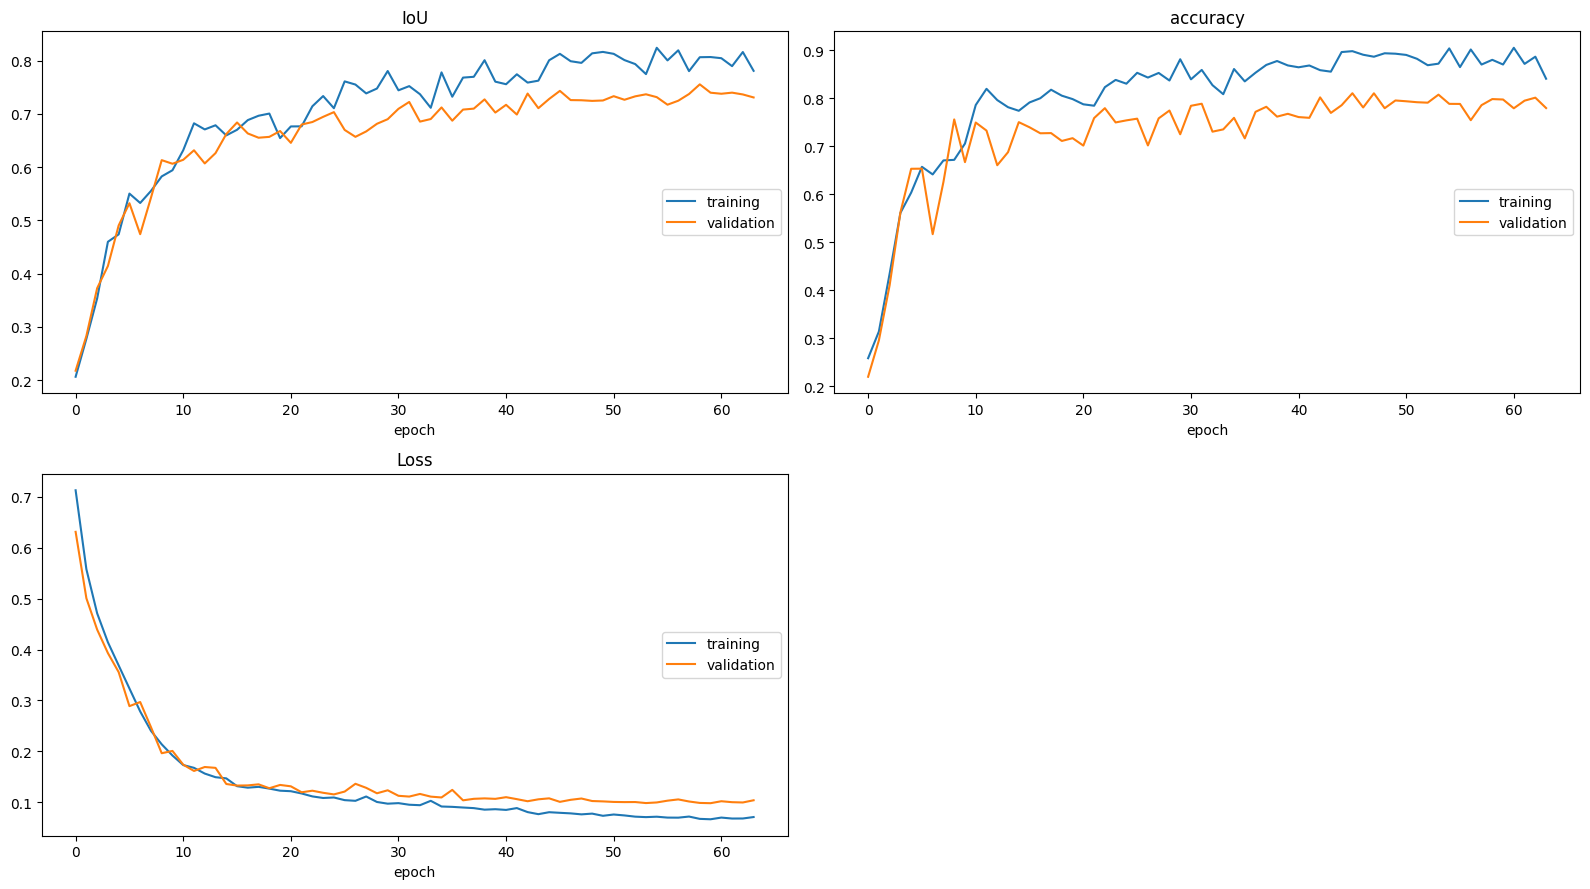

IoU
	training         	 (min:    0.206, max:    0.824, cur:    0.781)
	validation       	 (min:    0.218, max:    0.756, cur:    0.731)
accuracy
	training         	 (min:    0.258, max:    0.905, cur:    0.840)
	validation       	 (min:    0.219, max:    0.810, cur:    0.779)
Loss
	training         	 (min:    0.067, max:    0.713, cur:    0.071)
	validation       	 (min:    0.098, max:    0.631, cur:    0.104)

  Early stopping at epoch 64

Training complete! Best validation loss: 0.0982


In [50]:
print(f"\n{'='*60}")
print(f"STARTING FULL DATASET TRAINING")
print(f"{'='*60}")
print(f"Epochs: {TrainingConfig.EPOCHS}")
print(f"Batch size:8")
print(f"Learning rate: {TrainingConfig.LEARNING_RATE}")
print(f"Weight decay: {TrainingConfig.WEIGHT_DECAY}")
print(f"{'='*60}\n")

try:
    main(
        model=model, 
        optimizer=optimizer, 
        scheduler=scheduler,
        ckpt_dir=CKPT_DIR, 
        device=DEVICE
    )
except RuntimeError as e:
    print(f" Error: {e}")
    torch.cuda.empty_cache()
    gc.collect()
except KeyboardInterrupt:
    print("\n  Training interrupted by user")
    torch.cuda.empty_cache()
    gc.collect()

In [41]:
def main_resume(*, model, optimizer, scheduler, start_epoch, ckpt_dir, device='cuda'):
    total_epochs = TrainingConfig.EPOCHS
    model.to(device, non_blocking=True)

    writer = SummaryWriter(log_dir=os.path.join(ckpt_dir, 'tboard_logs'))
    best_loss = float("inf")
    live_plot = PlotLosses(outputs=[MatplotlibPlot(cell_size=(8, 3)), ExtremaPrinter()])

    early_stop = EarlyStopping(
        patience=TrainingConfig.PATIENCE,
        min_delta=TrainingConfig.MIN_DELTA
    )

    # START FROM start_epoch instead of 0
    for epoch in range(start_epoch, total_epochs):
        current_epoch = epoch + 1
        torch.cuda.empty_cache()
        gc.collect()

        train_loss, train_metric, train_acc = train_one_epoch(
            model=model, loader=train_loader, optimizer=optimizer,
            num_classes=5, device=device, epoch_idx=current_epoch, total_epochs=total_epochs
        )

        valid_loss, valid_metric, valid_acc = validate(
            model=model, loader=val_loader, device=device,
            num_classes=5, epoch_idx=current_epoch, total_epochs=total_epochs
        )
        live_plot.update({
            "loss": train_loss,
            "val_loss": valid_loss,
            "accuracy": train_acc,
            "val_accuracy": valid_acc,
            "IoU": train_metric,
            "val_IoU": valid_metric
        })
        live_plot.send()

        writer.add_scalar('Loss/train', train_loss, current_epoch)
        writer.add_scalar('Loss/valid', valid_loss, current_epoch)
        writer.add_scalar('Accuracy/train', train_acc, current_epoch)
        writer.add_scalar('Accuracy/valid', valid_acc, current_epoch)
        writer.add_scalar('IoU/train', train_metric, current_epoch)
        writer.add_scalar('IoU/valid', valid_metric, current_epoch)
        writer.add_scalar('LR', optimizer.param_groups[0]['lr'], current_epoch)

        # Step scheduler
        scheduler.step()

        # Early stopping check
        if early_stop(valid_loss):
            print(f"\n  Early stopping at epoch {current_epoch}")
            break

        # Periodic checkpoint
        if current_epoch % 10 == 0:
            print(f"Saving checkpoint at epoch {current_epoch}...")
            checkpoint_dict = {
                "opt": optimizer.state_dict(),
                "model": model.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch": current_epoch
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, f"ckpt_epoch_{current_epoch}.tar"))
            print("Done.")

        # Save best model
        if valid_loss < best_loss:
            best_loss = valid_loss
            print(f"\u2705 Model improved (loss: {valid_loss:.4f}). Saving...", end="")
            checkpoint_dict = {
                "opt": optimizer.state_dict(),
                "model": model.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch": current_epoch
            }
            torch.save(checkpoint_dict, os.path.join(ckpt_dir, "ckpt_best.tar"))
            del checkpoint_dict
            print("Done.\n")

    writer.close()
    print(f"\n{'='*60}")
    print(f"Training complete! Best validation loss: {best_loss:.4f}")
    print(f"{'='*60}")
    return


def resume_training_from_checkpoint(checkpoint_path, train_loader, val_loader, ckpt_dir, device='cuda'):
      """Resume training from a checkpoint file"""

      # Load checkpoint
      print(f"Loading checkpoint from: {checkpoint_path}")
      checkpoint = torch.load(checkpoint_path, map_location=device)

      # Recreate model and optimizer
      model = UNet3D(in_channels=3, out_channels=5).to(device)
      optimizer = AdamW(
          model.parameters(),
          lr=TrainingConfig.LEARNING_RATE,
          weight_decay=TrainingConfig.WEIGHT_DECAY
      )
      scheduler = CosineAnnealingLR(optimizer, T_max=TrainingConfig.EPOCHS, eta_min=1e-6)

      # Load states
      model.load_state_dict(checkpoint['model'])
      optimizer.load_state_dict(checkpoint['opt'])
      scheduler.load_state_dict(checkpoint['scheduler'])
      start_epoch = checkpoint['epoch']

      print(f"Resuming from epoch {start_epoch}")

      # Continue training
      main_resume(
          model=model,
          optimizer=optimizer,
          scheduler=scheduler,
          start_epoch=start_epoch,
          ckpt_dir=ckpt_dir,
          device=device
      )

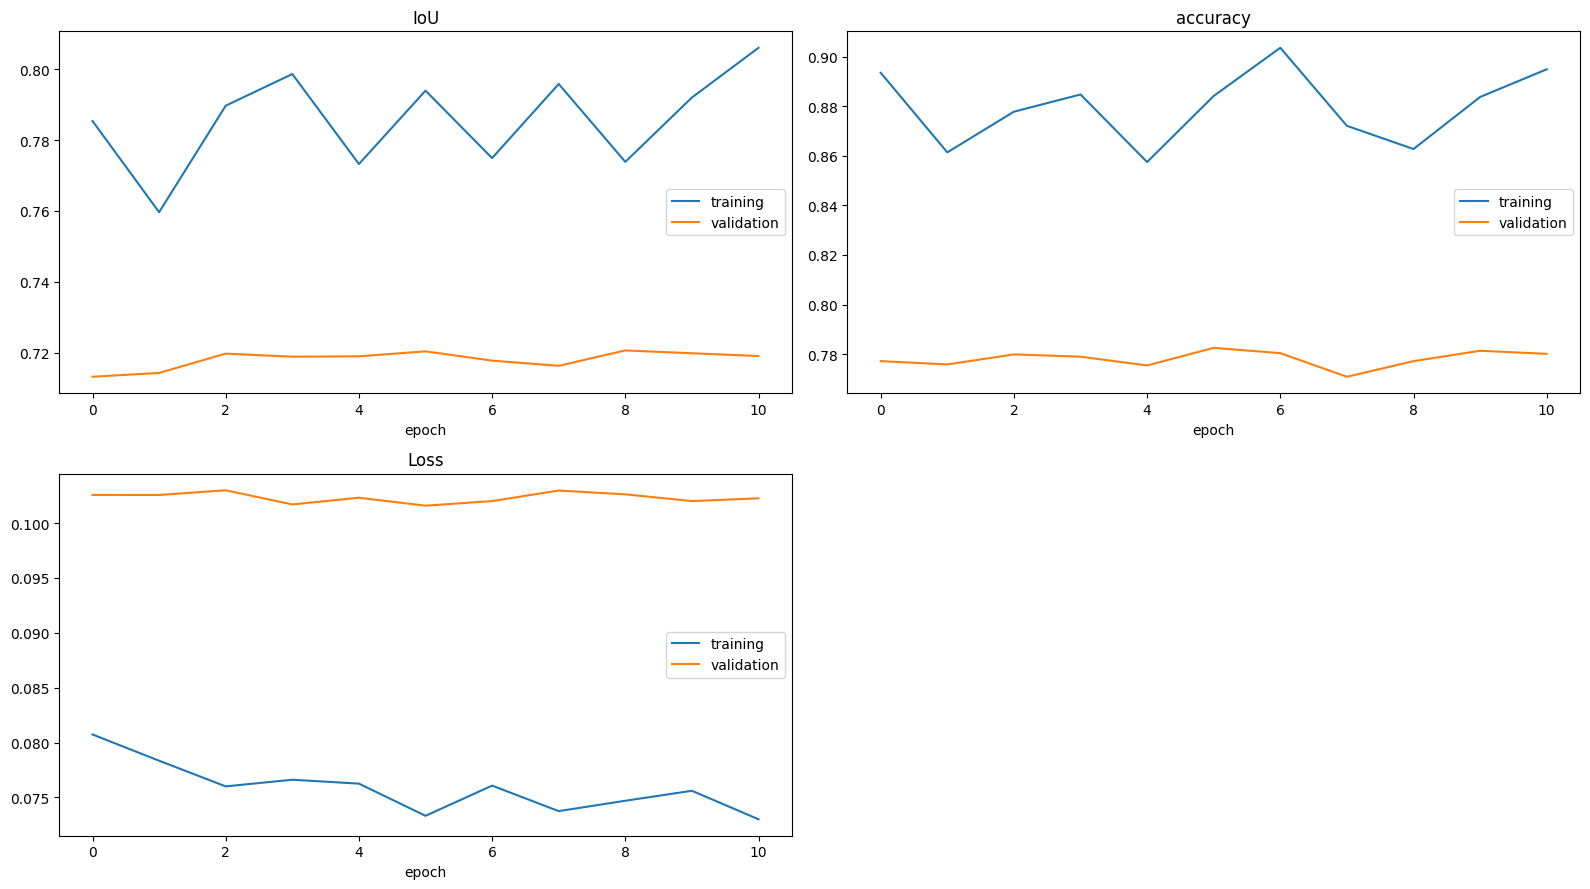

IoU
	training         	 (min:    0.760, max:    0.806, cur:    0.806)
	validation       	 (min:    0.713, max:    0.721, cur:    0.719)
accuracy
	training         	 (min:    0.857, max:    0.904, cur:    0.895)
	validation       	 (min:    0.771, max:    0.783, cur:    0.780)
Loss
	training         	 (min:    0.073, max:    0.081, cur:    0.073)
	validation       	 (min:    0.102, max:    0.103, cur:    0.102)

  Early stopping at epoch 51

Training complete! Best validation loss: 0.1016


In [42]:
checkpoint_file_path = '/teamspace/studios/this_studio/model_checkpoint/3D_UNet_Brats2024/version_0/ckpt_epoch_40.tar'

try:
    resume_training_from_checkpoint(
        checkpoint_path=checkpoint_file_path,
        train_loader=train_loader,
        val_loader=val_loader,
        ckpt_dir=CKPT_DIR,
        device=DEVICE
    )
except RuntimeError as e:
    print(f" Error: {e}")
    torch.cuda.empty_cache()
    gc.collect()
except KeyboardInterrupt:
    print("\n  Training interrupted by user")
    torch.cuda.empty_cache()
    gc.collect()

In [46]:
# In notebook cell:
torch.cuda.empty_cache()
import gc
gc.collect()

# Check memory cleared
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU memory: 3.81 GB
